# Transfer Learning e Introdução a Transformers
### Disciplina: Inteligência Artificial — Graduação em Ciência da Computação

---

## Objetivos da Aula

Ao final desta aula, você será capaz de:
- Entender o conceito de **Transfer Learning** e por que ele é a abordagem padrão em visão computacional moderna
- Diferenciar **feature extraction** (congelar a base) de **fine-tuning** (descongelar camadas)
- Reaproveitar uma **CNN pré-treinada** (MobileNetV2) para um novo problema de classificação
- Compreender a intuição do **mecanismo de atenção (self-attention)**
- Ter uma visão geral da arquitetura **Transformer** e por que ela substituiu RNNs em muitas tarefas
- Usar modelos pré-treinados da **Hugging Face** para tarefas de NLP em poucas linhas de código

## Conexão com as aulas anteriores

Em aulas anteriores treinamos uma CNN do zero para o MNIST — um dataset pequeno e simples. Hoje veremos que, para problemas mais complexos, **raramente treinamos do zero**: reaproveitamos redes já treinadas em milhões de imagens (ImageNet). Na aula anterior vimos RNN/LSTM para sequências; os Transformers são a evolução dessa linha, usando **atenção** em vez de recorrência.

## 1. Configuração do Ambiente

In [ ]:
!pip install transformers -q

import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)

print('TensorFlow:', tf.__version__)

TensorFlow: 2.20.0


## 2. Transfer Learning: Reaproveitando Conhecimento

**Ideia central**: uma rede treinada em um dataset gigantesco (ex: ImageNet, 1,2 milhões de imagens, 1000 classes) já aprendeu a detectar **características genéricas** — bordas, texturas, formas, padrões — nas primeiras camadas. Essas características são úteis para *qualquer* tarefa de visão, não apenas para a tarefa original.

| Estratégia | O que é feito | Quando usar |
|---|---|---|
| **Feature extraction** | Congela todos os pesos da base pré-treinada; treina apenas um novo classificador no topo | Dataset pequeno, problema parecido com o original |
| **Fine-tuning** | Descongela as últimas camadas da base e as treina com taxa de aprendizado baixa, junto com o novo classificador | Dataset um pouco maior, quando feature extraction não é suficiente |
| **Treino do zero** | Inicializa pesos aleatoriamente e treina tudo | Dataset muito grande e/ou domínio muito diferente (ex: imagens de satélite, raio-X) |

Vamos aplicar as duas primeiras estratégias usando a **MobileNetV2**, uma CNN pré-treinada na ImageNet, leve e rápida.

## 3. Carregando o Dataset — Cats vs Dogs

Vamos usar o dataset `cats_and_dogs_filtered` disponibilizado pelo Google, redimensionando as imagens para 160×160 (tamanho esperado pela MobileNetV2).

Extraindo arquivo zip local: /content/cats_and_dogs_filtered.zip para /content
Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Classes: ['cat', 'dog']
Lotes de treino: 63  |  Lotes de validação: 32


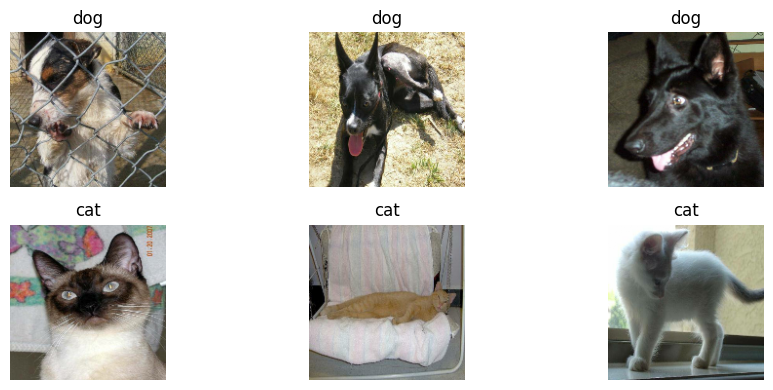

In [ ]:
import zipfile

IMG_SIZE = 160
BATCH_SIZE = 32

# --- MODIFICAÇÃO: Usar arquivo zip local se disponível ---
# Para usar este código, você precisa fazer o upload do arquivo
# 'cats_and_dogs_filtered.zip' para o diretório /content/ no Colab.
# Baixe-o manualmente e use o ícone de pasta (Files) > Upload para enviá-lo.

local_zip_path = '/content/cats_and_dogs_filtered.zip'
extracted_dir_name = 'cats_and_dogs_filtered'
PATH = os.path.join(os.path.dirname(local_zip_path), extracted_dir_name) # Será /content/cats_and_dogs_filtered

# Verifica se o diretório extraído já existe para evitar re-extração
if not os.path.exists(PATH):
    if os.path.exists(local_zip_path):
        print(f"Extraindo arquivo zip local: {local_zip_path} para {os.path.dirname(PATH)}")
        with zipfile.ZipFile(local_zip_path, 'r') as zip_ref:
            zip_ref.extractall(os.path.dirname(PATH)) # Extrai para /content/
    else:
        # Fallback se o arquivo local não for encontrado
        raise FileNotFoundError(f"Erro: Arquivo zip local '{local_zip_path}' não encontrado.\nPor favor, faça o upload do arquivo zip para /content/ ou verifique o caminho.")
else:
    print(f"Dataset já extraído em {PATH}.")

# --- FIM DA MODIFICAÇÃO ---


train_dir = os.path.join(PATH, 'train')
val_dir   = os.path.join(PATH, 'validation')

ds_train_proc = keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    seed=42
).map(lambda x, y: (x / 255.0, y)).prefetch(1)

ds_val_proc = keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='binary',
    seed=42
).map(lambda x, y: (x / 255.0, y)).prefetch(1)

class_names = ['cat', 'dog']
print(f'Classes: {class_names}')
print(f'Lotes de treino: {len(ds_train_proc)}  |  Lotes de validação: {len(ds_val_proc)}')

# Visualiza algumas amostras
plt.figure(figsize=(10, 4))
for imagens, rotulos in ds_train_proc.take(1):
    for i in range(6):
        plt.subplot(2, 3, i + 1)
        plt.imshow(imagens[i].numpy())
        plt.title(class_names[int(rotulos[i].numpy())])
        plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Feature Extraction — Congelando a Base Pré-treinada

Carregamos a MobileNetV2 **sem** a camada de classificação original (`include_top=False`), com os pesos da ImageNet. Em seguida, **congelamos** (`base.trainable = False`) e adicionamos um novo classificador no topo para a nossa tarefa (gato vs. cachorro).

In [ ]:
base_model = keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False  # congela todos os pesos da base

print(f'Camadas na base: {len(base_model.layers)}')
print(f'Parâmetros treináveis na base: {sum(np.prod(w.shape) for w in base_model.trainable_weights)}')

modelo_fe = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')
])

modelo_fe.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                   loss='binary_crossentropy', metrics=['accuracy'])
modelo_fe.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Camadas na base: 154
Parâmetros treináveis na base: 0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_160            │ (None, 5, 5, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
hist_fe = modelo_fe.fit(ds_train_proc, validation_data=ds_val_proc, epochs=5, verbose=1)

print(f"\nAcurácia final (treino):    {hist_fe.history['accuracy'][-1]:.4f}")
print(f"Acurácia final (validação): {hist_fe.history['val_accuracy'][-1]:.4f}")

Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 44s 638ms/step - accuracy: 0.8935 - loss: 0.2606 - val_accuracy: 0.9580 - val_loss: 0.1125
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 40s 625ms/step - accuracy: 0.9670 - loss: 0.0974 - val_accuracy: 0.9610 - val_loss: 0.0906
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 646ms/step - accuracy: 0.9710 - loss: 0.0808 - val_accuracy: 0.9630 - val_loss: 0.0830
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 52s 832ms/step - accuracy: 0.9745 - loss: 0.0663 - val_accuracy: 0.9680 - val_loss: 0.0786
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 44s 698ms/step - accuracy: 0.9770 - loss: 0.0576 - val_accuracy: 0.9710 - val_loss: 0.0782

Acurácia final (treino):    0.9770
Acurácia final (validação): 0.9710


## 5. Fine-Tuning — Descongelando as Últimas Camadas

Agora descongelamos as camadas finais da base e continuamos o treino com uma **taxa de aprendizado bem menor** (ex: 1e-5). Isso permite que os filtros mais especializados (camadas finais, que capturam padrões mais abstratos) se ajustem ao nosso domínio, sem destruir o conhecimento geral aprendido nas camadas iniciais.

> **Por que LR baixa?** Os pesos pré-treinados já estão próximos de um bom mínimo. Atualizações grandes destruiriam rapidamente o conhecimento útil já acumulado (*catastrophic forgetting*).

In [ ]:
base_model.trainable = True

# Congela tudo, exceto as últimas 30 camadas
for camada in base_model.layers[:-30]:
    camada.trainable = False

print(f'Parâmetros treináveis após descongelar: {sum(np.prod(w.shape) for w in base_model.trainable_weights)}')

modelo_fe.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),
                   loss='binary_crossentropy', metrics=['accuracy'])

hist_ft = modelo_fe.fit(ds_train_proc, validation_data=ds_val_proc, epochs=5, verbose=1)

print(f"\nAcurácia final (treino):    {hist_ft.history['accuracy'][-1]:.4f}")
print(f"Acurácia final (validação): {hist_ft.history['val_accuracy'][-1]:.4f}")

Parâmetros treináveis após descongelar: 1526400
Epoch 1/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 67s 930ms/step - accuracy: 0.8990 - loss: 0.2269 - val_accuracy: 0.9680 - val_loss: 0.0777
Epoch 2/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 59s 946ms/step - accuracy: 0.9540 - loss: 0.1235 - val_accuracy: 0.9630 - val_loss: 0.0843
Epoch 3/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 83s 961ms/step - accuracy: 0.9675 - loss: 0.1022 - val_accuracy: 0.9660 - val_loss: 0.0835
Epoch 4/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 74s 831ms/step - accuracy: 0.9745 - loss: 0.0736 - val_accuracy: 0.9660 - val_loss: 0.0829
Epoch 5/5
63/63 ━━━━━━━━━━━━━━━━━━━━ 54s 858ms/step - accuracy: 0.9740 - loss: 0.0706 - val_accuracy: 0.9670 - val_loss: 0.0841

Acurácia final (treino):    0.9740
Acurácia final (validação): 0.9670


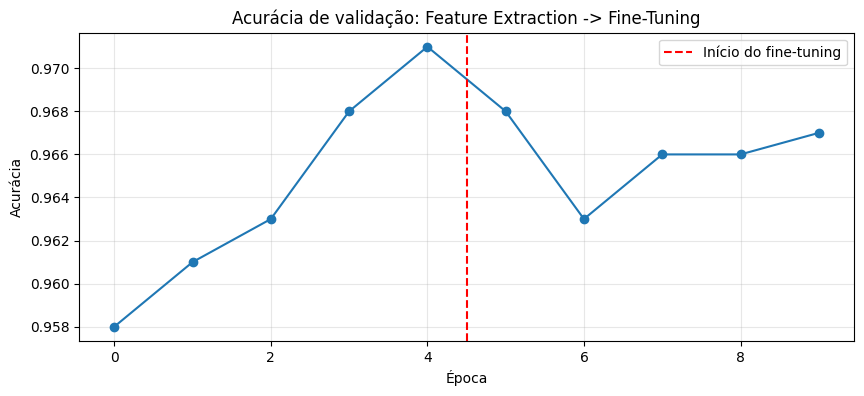

In [ ]:
acc_total = hist_fe.history['val_accuracy'] + hist_ft.history['val_accuracy']

plt.figure(figsize=(10, 4))
plt.plot(acc_total, marker='o')
plt.axvline(x=len(hist_fe.history['val_accuracy']) - 0.5, color='red', linestyle='--',
             label='Início do fine-tuning')
plt.title('Acurácia de validação: Feature Extraction -> Fine-Tuning')
plt.xlabel('Época'); plt.ylabel('Acurácia')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

## 6. Mecanismo de Atenção (Self-Attention) — Intuição

Na aula anterior, vimos que RNN/LSTM processam sequências **passo a passo**, o que é lento e dificulta capturar dependências muito distantes. O mecanismo de **atenção** permite que cada elemento da sequência "olhe" diretamente para **todos os outros elementos**, calculando o quanto cada um é relevante para o atual.

Para cada posição, calculamos três vetores a partir da entrada $x$:

- **Query (Q)**: "o que estou procurando?"
- **Key (K)**: "o que eu represento?"
- **Value (V)**: "qual informação eu carrego?"

A saída de atenção é uma média ponderada dos *Values*, com pesos dados pela similaridade entre *Query* e *Key*:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$

O exemplo abaixo calcula a atenção "na mão" para uma sequência de 4 posições com vetores aleatórios, apenas para visualizar a matriz de pesos resultante.

Matriz de pesos de atenção (cada linha soma 1):
[[0.301 0.301 0.191 0.207]
 [0.258 0.382 0.244 0.116]
 [0.09  0.076 0.122 0.712]
 [0.82  0.086 0.023 0.072]]


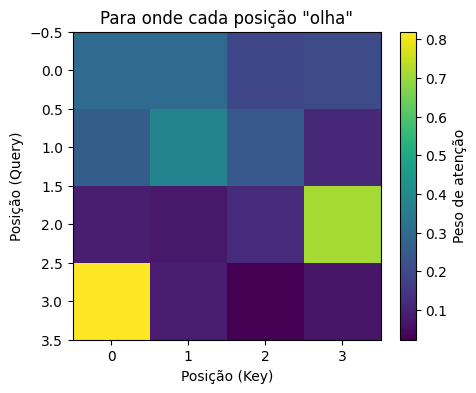

In [ ]:
np.random.seed(0)

seq_len, d_k = 4, 8  # 4 posições na sequência, vetores de dimensão 8
Q = np.random.randn(seq_len, d_k)
K = np.random.randn(seq_len, d_k)
V = np.random.randn(seq_len, d_k)

def softmax(x, axis=-1):
    e = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

scores = (Q @ K.T) / np.sqrt(d_k)
pesos_atencao = softmax(scores)
saida = pesos_atencao @ V

print('Matriz de pesos de atenção (cada linha soma 1):')
print(np.round(pesos_atencao, 3))

plt.figure(figsize=(5, 4))
plt.imshow(pesos_atencao, cmap='viridis')
plt.colorbar(label='Peso de atenção')
plt.title('Para onde cada posição "olha"')
plt.xlabel('Posição (Key)'); plt.ylabel('Posição (Query)')
plt.show()

## 7. Transformers: Visão Geral da Arquitetura

Introduzidos no artigo *"Attention Is All You Need"* (2017), os Transformers eliminam completamente a recorrência, usando apenas **self-attention** e camadas densas. Principais componentes:

| Componente | Função |
|---|---|
| **Embedding** | Converte tokens (palavras, sub-palavras) em vetores numéricos |
| **Positional Encoding** | Injeta informação de *posição*, já que não há recorrência para indicar ordem |
| **Multi-Head Attention** | Várias "cabeças" de atenção em paralelo, cada uma aprendendo um tipo diferente de relação entre tokens |
| **Feed-Forward + Residual + LayerNorm** | Processamento posição a posição, com conexões residuais para estabilizar o treino |
| **Encoder / Decoder** | Encoder lê a sequência de entrada; Decoder gera a sequência de saída (ex: tradução) |

**Por que Transformers dominaram NLP (e cada vez mais visão, com Vision Transformers)?**
- **Paralelização**: todas as posições são processadas simultaneamente (RNNs processam sequencialmente)
- **Dependências de longo alcance**: atenção conecta diretamente quaisquer duas posições, sem o gargalo do gradiente desvanecente
- **Escalabilidade**: a mesma arquitetura, com mais dados e parâmetros, deu origem a BERT, GPT, T5, e modelos de linguagem atuais

## 8. Na Prática: Modelos Pré-treinados com Hugging Face

A biblioteca `transformers` (Hugging Face) disponibiliza milhares de modelos Transformer pré-treinados, prontos para uso via `pipeline` — exatamente o mesmo princípio de Transfer Learning da seção 2, mas aplicado a texto.

In [ ]:
from transformers import pipeline

classificador_sentimento = pipeline('sentiment-analysis')

frases = [
    'This movie was absolutely fantastic, I loved every minute!',
    'The service was terrible and the food was cold.',
    'It was an okay experience, nothing special.',
]

for frase in frases:
    resultado = classificador_sentimento(frase)[0]
    print(f"'{frase}'\n  -> {resultado['label']} (confiança: {resultado['score']:.3f})\n")

[transformers] No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f.
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

'This movie was absolutely fantastic, I loved every minute!'
  -> POSITIVE (confiança: 1.000)

'The service was terrible and the food was cold.'
  -> NEGATIVE (confiança: 1.000)

'It was an okay experience, nothing special.'
  -> NEGATIVE (confiança: 0.929)



In [ ]:
classificador_zero_shot = pipeline('zero-shot-classification')

texto = 'The new GPU released this week delivers twice the performance at the same price.'
categorias = ['hardware', 'mercado financeiro', 'entretenimento']

resultado = classificador_zero_shot(texto, candidate_labels=categorias)

for label, score in zip(resultado['labels'], resultado['scores']):
    print(f'{label:<12} {score:.3f}')

[transformers] No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1.
Using a pipeline without specifying a model name and revision in production is not recommended.


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

hardware     0.921
entretenimento 0.044
mercado financeiro 0.035


---
## 9. Exercícios

### Exercício 1 — Outra Arquitetura Pré-treinada
Repita o experimento de feature extraction (seção 4) substituindo `keras.applications.MobileNetV2` por `keras.applications.ResNet50` (ajuste `input_shape` conforme necessário). Compare acurácia de validação e tempo de treino com a MobileNetV2.

In [ ]:
# Seu código aqui: feature extraction com ResNet50 e comparação com MobileNetV2


### Exercício 2 — Quantidade de Camadas Descongeladas
Na seção 5, descongelamos as últimas 30 camadas da MobileNetV2. Repita o fine-tuning descongelando apenas as últimas **10** camadas, e depois **todas** as camadas. Compare a acurácia de validação e discuta: descongelar mais camadas sempre é melhor?

In [ ]:
# Seu código aqui: teste diferentes quantidades de camadas descongeladas


### Exercício 3 — Zero-Shot Classification em Português
Usando `pipeline('zero-shot-classification', model='joeddav/xlm-roberta-large-xnli')` (modelo multilíngue), classifique 3 frases em português de sua escolha em categorias também em português. Os resultados fazem sentido?

In [ ]:
# Seu código aqui: zero-shot classification com modelo multilíngue


### Exercício 4 — Variando a Sequência na Demonstração de Atenção
Na seção 6, geramos `Q`, `K`, `V` aleatoriamente para uma sequência de 4 posições. Refaça o experimento com `seq_len = 8` e `d_k = 16`. A matriz de pesos de atenção continua somando 1 em cada linha? O que acontece com o padrão visual do heatmap ao aumentar `seq_len`?

In [ ]:
# Seu código aqui: refaça a demonstração de atenção com seq_len=8 e d_k=16


---
## 10. Resumo: Panorama Geral da Disciplina

```
AULA  TEMA                              CONCEITO CENTRAL
------------------------------------------------------------------------
1     Reconhecimento de dígitos          MLP, CNN, convoluções
2     Árvores e Random Forest            Árvores de decisão, bagging
3     Técnicas de melhoria                Normalização, SMOTE, CV, regularização, boosting
4     Clustering & PCA                    Aprendizado não supervisionado
5     SVM e Naive Bayes                   Margem máxima, modelos probabilísticos
6     RNN e LSTM                          Dados sequenciais, memória, gates
7     Transfer Learning & Transformers    Reaproveitar modelos, atenção
```

**Mensagem final**: a maior parte da IA aplicada hoje não é treinar um modelo do zero, e sim **adaptar modelos pré-treinados** com as técnicas certas de pré-processamento, validação e regularização vistas ao longo do curso.

In [ ]:
print('=== Resumo dos conceitos desta aula ===')
conceitos = [
    '- Transfer Learning: reaproveita representações aprendidas em datasets grandes',
    '- Feature extraction: congela a base, treina apenas o classificador novo',
    '- Fine-tuning: descongela as últimas camadas, treina com LR baixa',
    '- Self-attention: cada posição da sequência "olha" para todas as outras',
    '- Q, K, V: query, key e value -> base do mecanismo de atenção',
    '- Transformer: dispensa recorrência, paraleliza o processamento da sequência',
    '- Hugging Face pipeline: acesso a modelos pré-treinados em poucas linhas',
]
for c in conceitos:
    print(c)

---
## Referências

1. Vaswani, A. et al. (2017). *Attention Is All You Need*. NeurIPS.
2. Sandler, M. et al. (2018). *MobileNetV2: Inverted Residuals and Linear Bottlenecks*. CVPR.
3. Devlin, J. et al. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. NAACL.
4. Wolf, T. et al. (2020). *Transformers: State-of-the-Art Natural Language Processing*. EMNLP (Hugging Face).
5. Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow* (3ª ed.). O'Reilly — Capítulos 14 (CNNs/Transfer Learning) e 16 (Transformers/Attention).
6. Documentação Hugging Face: https://huggingface.co/docs/transformers